# 🔹 Why Padding & Stride Matter

In CNNs, padding and stride control:

Output feature map size

How much spatial information is kept

Computational cost

# 🔹 Stride
📌 What Is Stride?

Stride is the number of pixels the filter moves each time it slides over the image.

📐 Effect of Stride

Stride = 1 → fine detail, larger output

Stride = 2 → skips pixels, smaller output

📌 Larger stride = downsampling

🧠 Example

Input: 5×5, Filter: 3×3

| Stride | Output Size |
| ------ | ----------- |
| 1      | 3×3         |
| 2      | 2×2         |


# 🔹 Padding
📌 What Is Padding?

Padding adds extra pixels (usually zeros) around the image border.

👉 Prevents shrinking of feature maps.

# 🧠 Why Padding Is Needed

Keeps spatial size

Preserves edge information

Allows deeper CNNs

# 📌 Types of Padding
1️⃣ Valid Padding

No padding

Output size shrinks

2️⃣ Same Padding ⭐

Pads input so output size = input size

🧠 Padding Example

Input: 5×5, Filter: 3×3, Stride = 1

Padding	Output
Valid	3×3
Same	5×5
🔢 Output Size Formula (Very Important)
Output = (N − F + 2P) / S + 1


Where:

N = input size

F = filter size

P = padding

S = stride

# 🔄 Padding vs Stride (Quick Comparison)

| Feature         | Padding      | Stride           |
| --------------- | ------------ | ---------------- |
| Purpose         | Control size | Control movement |
| Adds pixels     | Yes          | No               |
| Reduces size    | No           | Yes              |
| Preserves edges | Yes          | No               |

# 🎯 How to Choose?

Same padding + stride 1 → Preserve information

Stride 2 → Downsampling

Padding needed → Small images / deep networks

🧠 One-Line Exam Answers

Stride: Controls how the filter moves across the image.

Padding: Adds extra pixels to preserve spatial dimensions.

💡 Interview Tip

❓ Why same padding is popular?
✔ Keeps feature map size
✔ Easier to design deep CNNs

# 🧩 Memory Trick
Stride → How far to move
Padding → Extra border

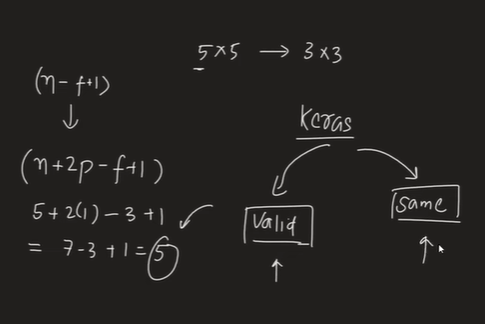

In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten
from keras import Sequential
from keras.datasets import mnist

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 51s 4us/step


In [3]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation='relu'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

c:\Users\Home\anaconda3\envs\eda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,002,698 (7.64 MB)

 Trainable params: 2,002,698 (7.64 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu'))
model.add(Conv2D(32,kernel_size=(3,3),padding='same',strides=(2,2), activation='relu'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [6]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,770 (335.04 KB)

 Trainable params: 85,770 (335.04 KB)

 Non-trainable params: 0 (0.00 B)

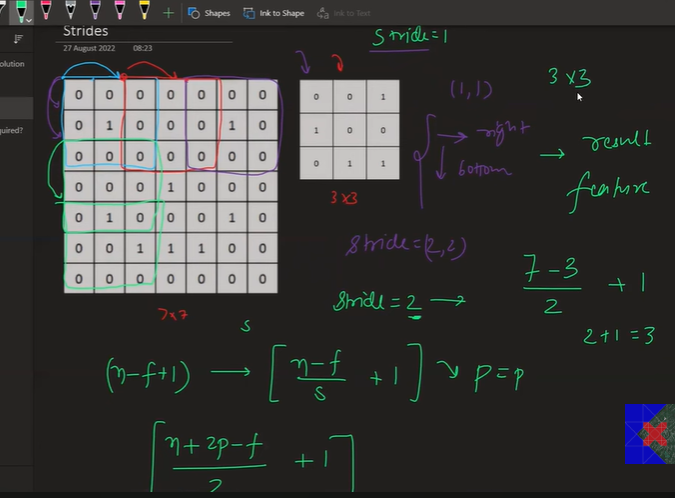

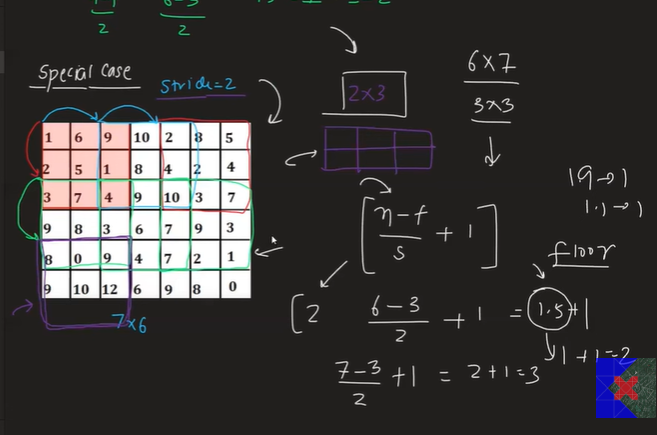

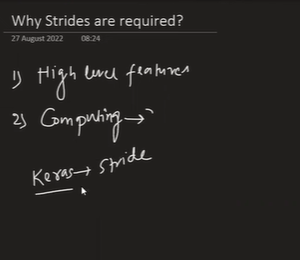